# 02 — Exploratory Data Analysis

Explore the merged TCGA Pan-Cancer TMB dataset:
- Summary statistics
- TMB distributions (raw vs log-transformed)
- TMB by cancer type
- Predictor distributions and bivariate relationships
- Correlation structure

In [1]:
import sys
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.plotting import set_style, save_fig, plot_tmb_distribution, plot_tmb_by_cancer_type

set_style()

FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

df = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "tmb_merged.parquet")
print(f"Loaded {df.shape[0]} samples, {df.shape[1]} columns")

Loaded 10953 samples, 104 columns


## 1. Summary Statistics

In [2]:
# Continuous variables
continuous_cols = ["age_at_diagnosis", "tmb", "log_tmb", "mutation_count",
                   "fraction_genome_altered", "aneuploidy_score", "msi_score_mantis"]
available_cont = [c for c in continuous_cols if c in df.columns]
print("=== Continuous Variables ===")
df[available_cont].describe().round(3)

=== Continuous Variables ===


,age_at_diagnosis,tmb,log_tmb,mutation_count,fraction_genome_altered,aneuploidy_score,msi_score_mantis
count,10815.000,10090.000,10090.000,10090.000,10753.000,10430.000,9712.000
mean,59.023,7.063,1.316,211.885,0.251,10.010,0.329
std,14.404,27.170,0.939,815.112,0.222,8.252,0.108
min,10.000,0.033,0.033,1.000,0.000,0.000,0.170
25%,50.000,0.933,0.659,28.000,0.070,3.000,0.292
50%,60.000,1.967,1.087,59.000,0.194,8.000,0.314
75%,70.000,4.467,1.699,134.000,0.386,16.000,0.330
max,90.000,856.567,6.754,25697.000,1.000,39.000,1.440


In [3]:
# Categorical variables
cat_cols = ["cancer_type", "sex", "msi_status", "tmb_high", "wgd_status"]
available_cat = [c for c in cat_cols if c in df.columns]
print("=== Categorical Variables ===")
for col in available_cat:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).to_string())

=== Categorical Variables ===

cancer_type:
cancer_type
Breast Cancer                          1084
Non-Small Cell Lung Cancer             1053
Esophagogastric Cancer                  622
Colorectal Cancer                       594
Endometrial Cancer                      586
Glioblastoma                            585
Ovarian Epithelial Tumor                585
Head and Neck Cancer                    523
Glioma                                  514
Renal Clear Cell Carcinoma              512
Thyroid Cancer                          499
Prostate Cancer                         494
Melanoma                                442
Bladder Cancer                          411
Hepatobiliary Cancer                    372
Renal Non-Clear Cell Carcinoma          348
Cervical Cancer                         297
Sarcoma                                 255
Leukemia                                200
Pancreatic Cancer                       184
Pheochromocytoma                        147
Thymic Epithelial Tu

## 2. TMB Distribution: Raw vs Log-Transformed

  Saved: tmb_distribution.png, tmb_distribution.pdf


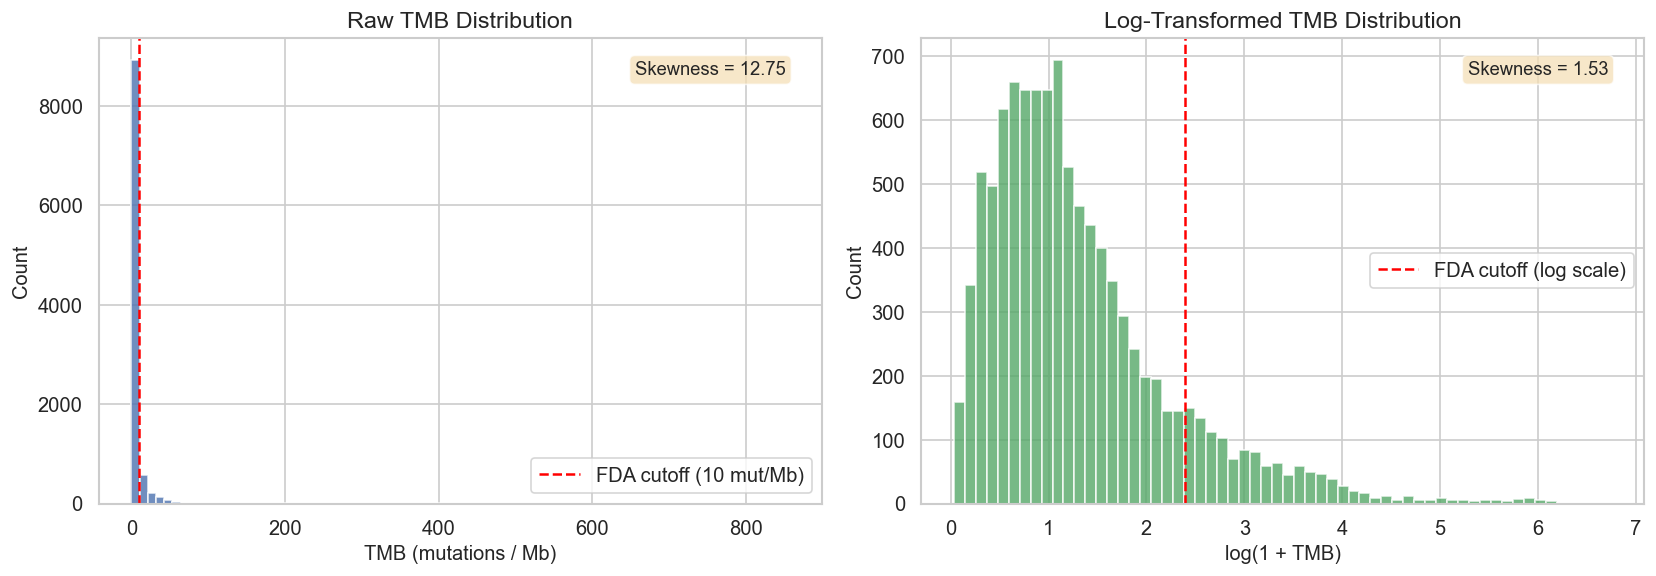

In [4]:
fig = plot_tmb_distribution(df)
save_fig(fig, "tmb_distribution", FIGURES_DIR)
plt.show()

In [5]:
# Skewness comparison
raw_skew = stats.skew(df["tmb"].dropna())
log_skew = stats.skew(df["log_tmb"].dropna())
print(f"Raw TMB skewness:  {raw_skew:.3f}")
print(f"Log TMB skewness:  {log_skew:.3f}")
print(f"\nLog-transform reduces skewness by {abs(raw_skew) - abs(log_skew):.1f} units")
print(f"=> Log-transformation is {'strongly' if abs(raw_skew) > 3 else 'moderately'} recommended")

Raw TMB skewness:  12.754
Log TMB skewness:  1.533

Log-transform reduces skewness by 11.2 units
=> Log-transformation is strongly recommended


## 3. TMB by Cancer Type

  Saved: tmb_by_cancer_type_box.png, tmb_by_cancer_type_box.pdf


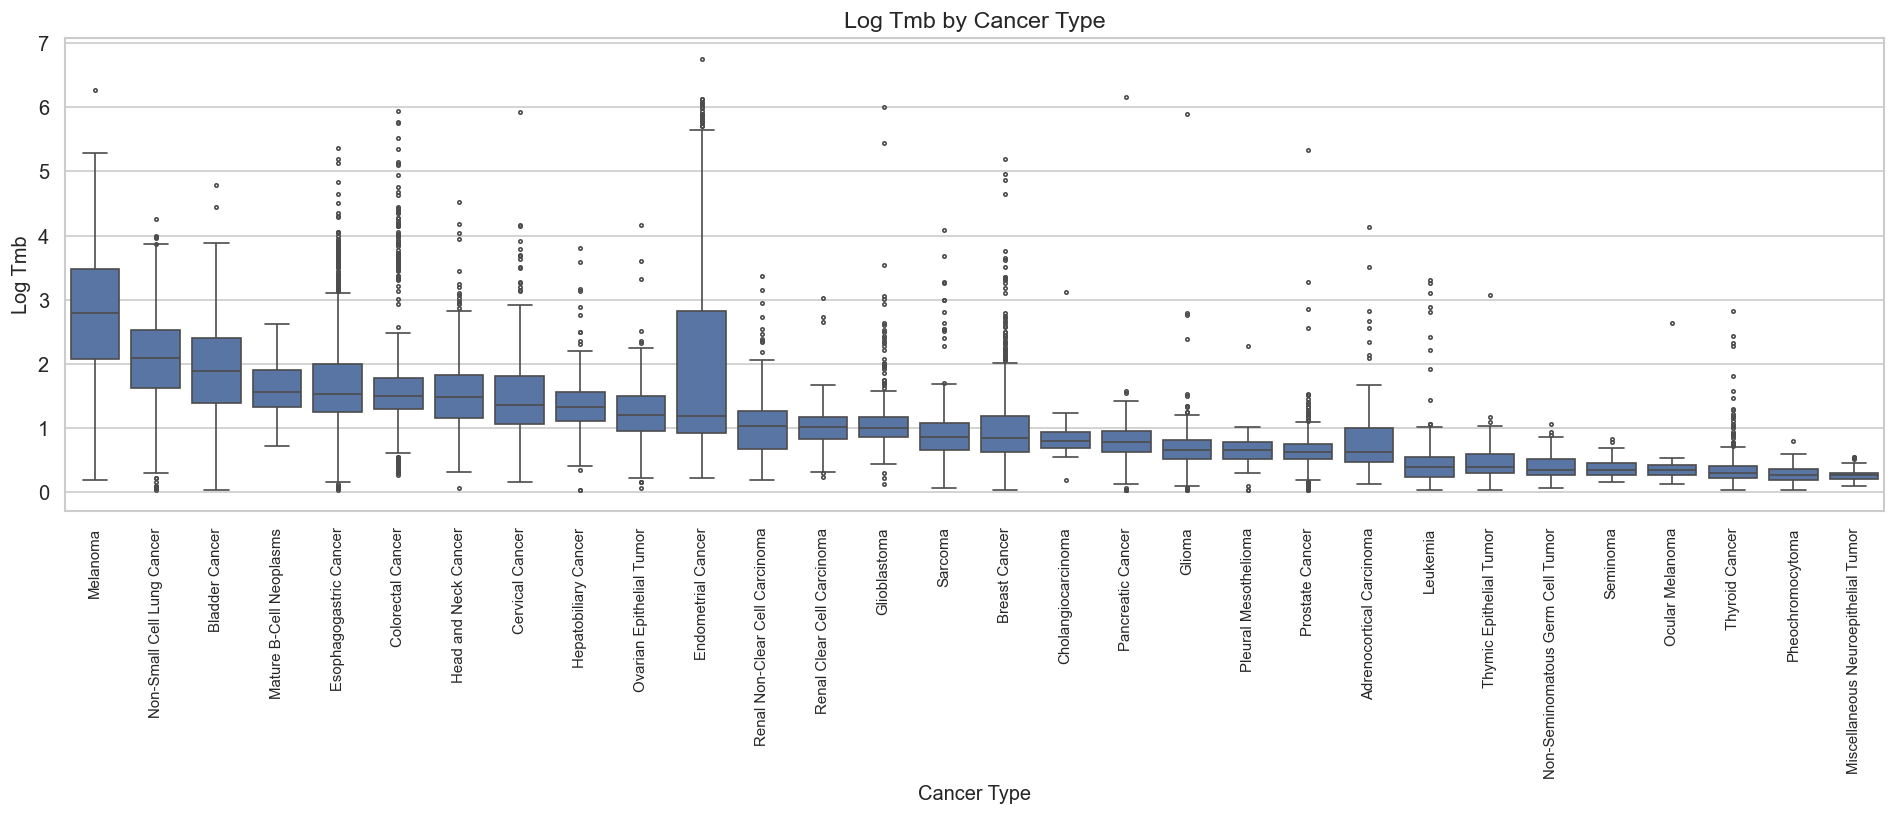

In [6]:
# Boxplot
fig = plot_tmb_by_cancer_type(df, kind="box", tmb_col="log_tmb")
save_fig(fig, "tmb_by_cancer_type_box", FIGURES_DIR)
plt.show()

  Saved: tmb_by_cancer_type_violin.png, tmb_by_cancer_type_violin.pdf


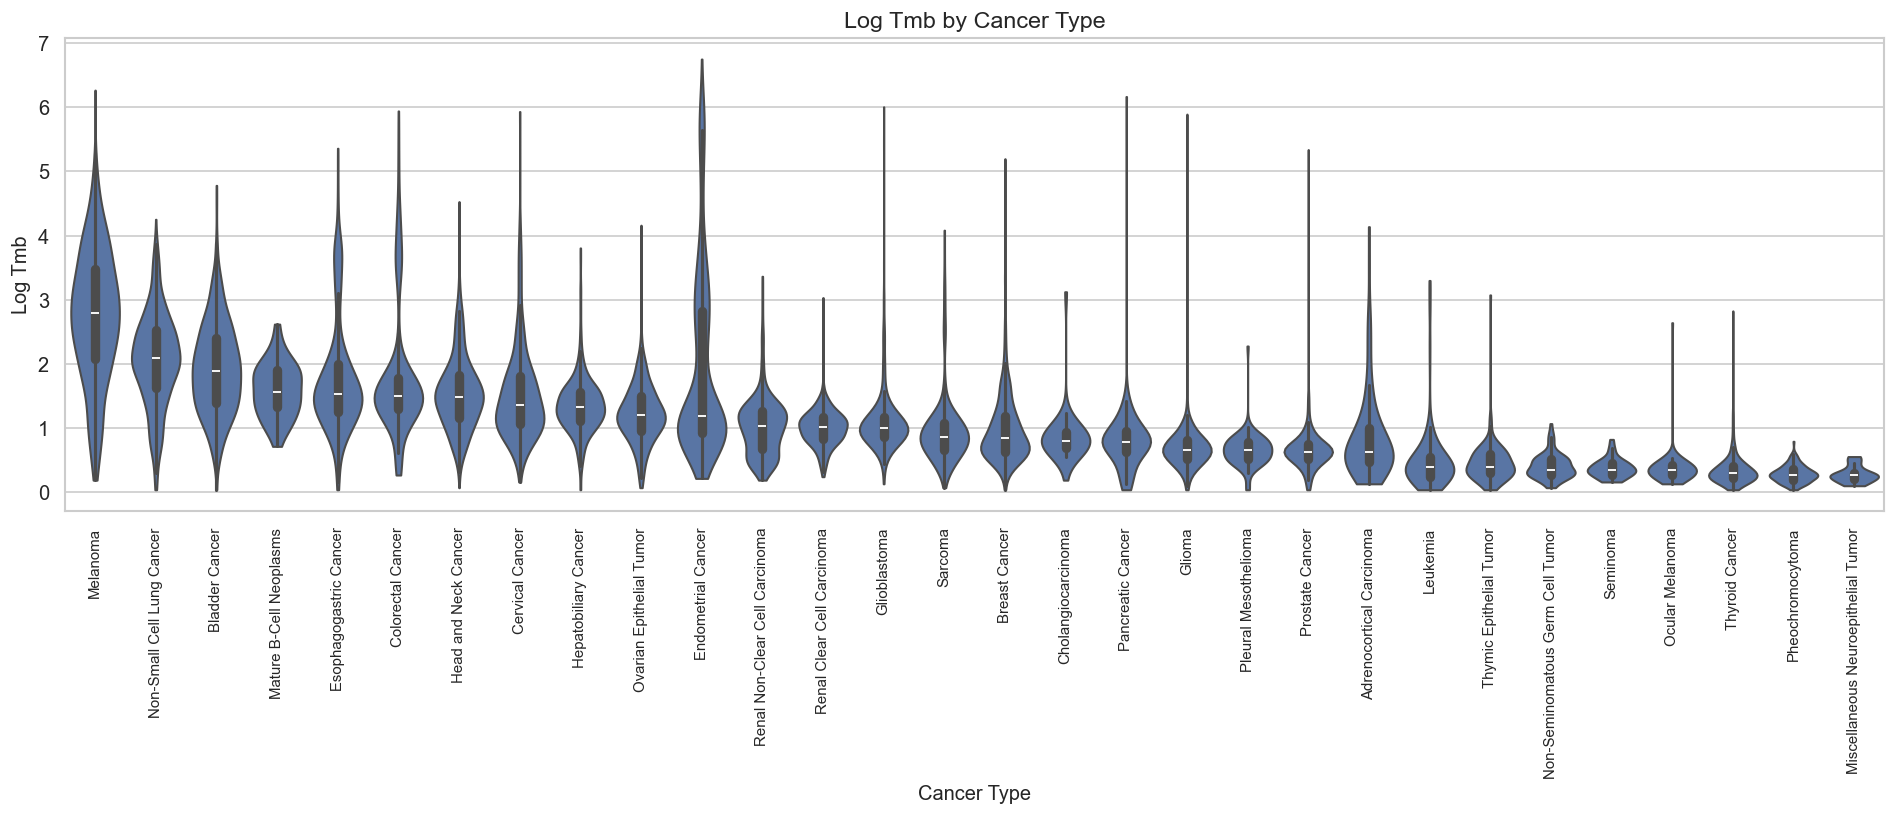

In [7]:
# Violin plot
fig = plot_tmb_by_cancer_type(df, kind="violin", tmb_col="log_tmb")
save_fig(fig, "tmb_by_cancer_type_violin", FIGURES_DIR)
plt.show()

  Saved: tmb_high_prevalence.png, tmb_high_prevalence.pdf


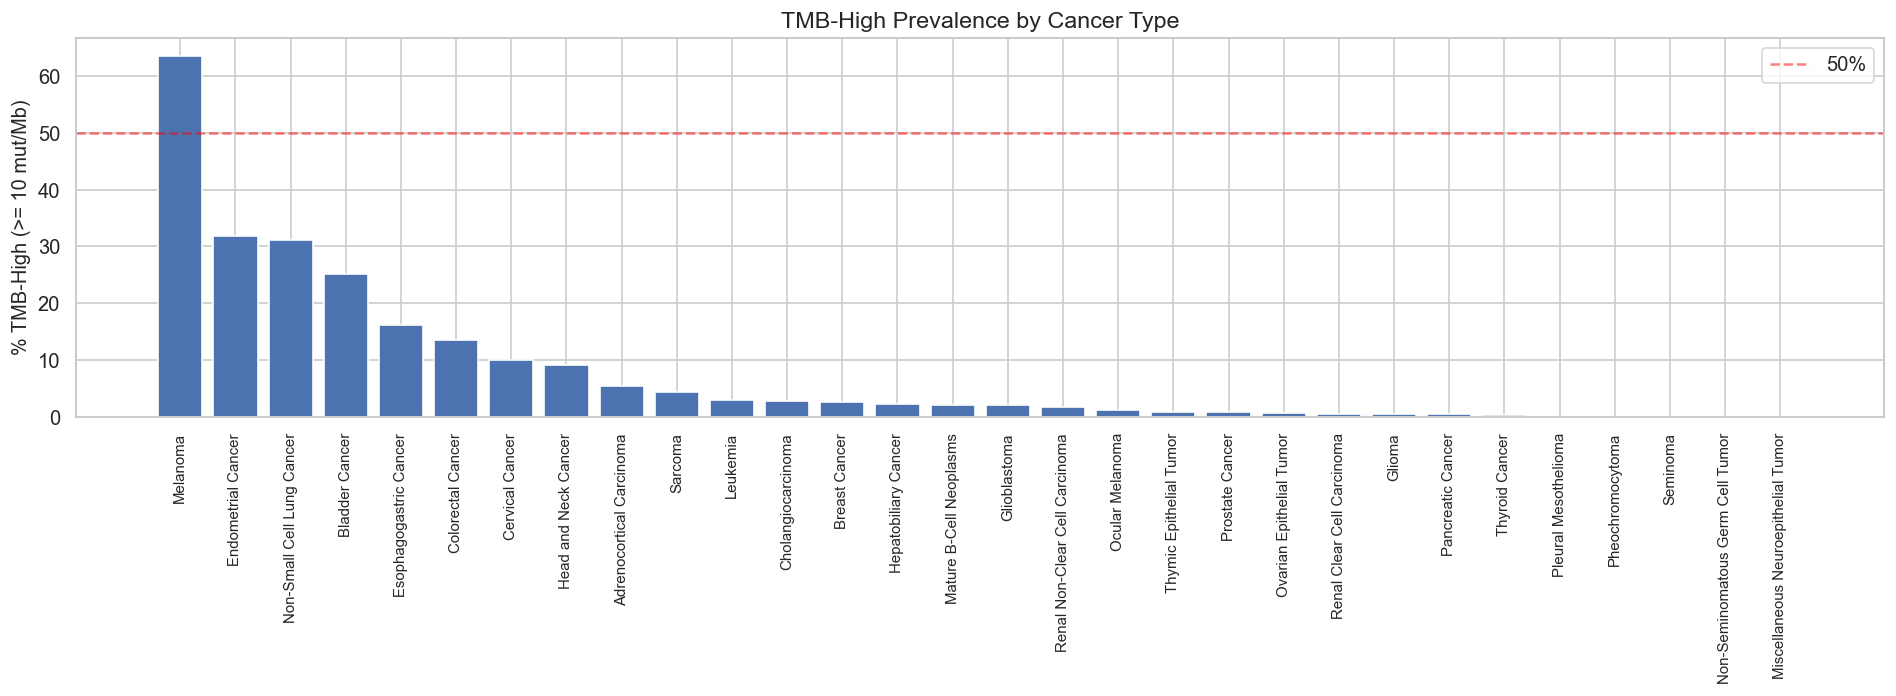


Top 10 cancer types by TMB-high prevalence:
                            prevalence_pct  n_high  n_total
cancer_type                                                
Melanoma                              63.6     281      442
Endometrial Cancer                    31.9     187      586
Non-Small Cell Lung Cancer            31.1     328     1053
Bladder Cancer                        25.1     103      411
Esophagogastric Cancer                16.1     100      622
Colorectal Cancer                     13.6      81      594
Cervical Cancer                       10.1      30      297
Head and Neck Cancer                   9.2      48      523
Adrenocortical Carcinoma               5.4       5       92
Sarcoma                                4.3      11      255


In [8]:
# TMB-high prevalence by cancer type
if "tmb_high" in df.columns and "cancer_type" in df.columns:
    prevalence = (
        df.groupby("cancer_type")["tmb_high"]
        .agg(["mean", "sum", "count"])
        .rename(columns={"mean": "prevalence", "sum": "n_high", "count": "n_total"})
        .sort_values("prevalence", ascending=False)
    )
    prevalence["prevalence_pct"] = (prevalence["prevalence"] * 100).round(1)

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.bar(range(len(prevalence)), prevalence["prevalence_pct"], color="#4C72B0")
    ax.set_xticks(range(len(prevalence)))
    ax.set_xticklabels(prevalence.index, rotation=90, fontsize=9)
    ax.axhline(y=50, color="red", ls="--", alpha=0.5, label="50%")
    ax.set_ylabel("% TMB-High (>= 10 mut/Mb)")
    ax.set_title("TMB-High Prevalence by Cancer Type")
    ax.legend()
    fig.tight_layout()
    save_fig(fig, "tmb_high_prevalence", FIGURES_DIR)
    plt.show()

    print("\nTop 10 cancer types by TMB-high prevalence:")
    print(prevalence[["prevalence_pct", "n_high", "n_total"]].head(10).to_string())

## 4. Predictor Distributions

  Saved: predictor_distributions_continuous.png, predictor_distributions_continuous.pdf


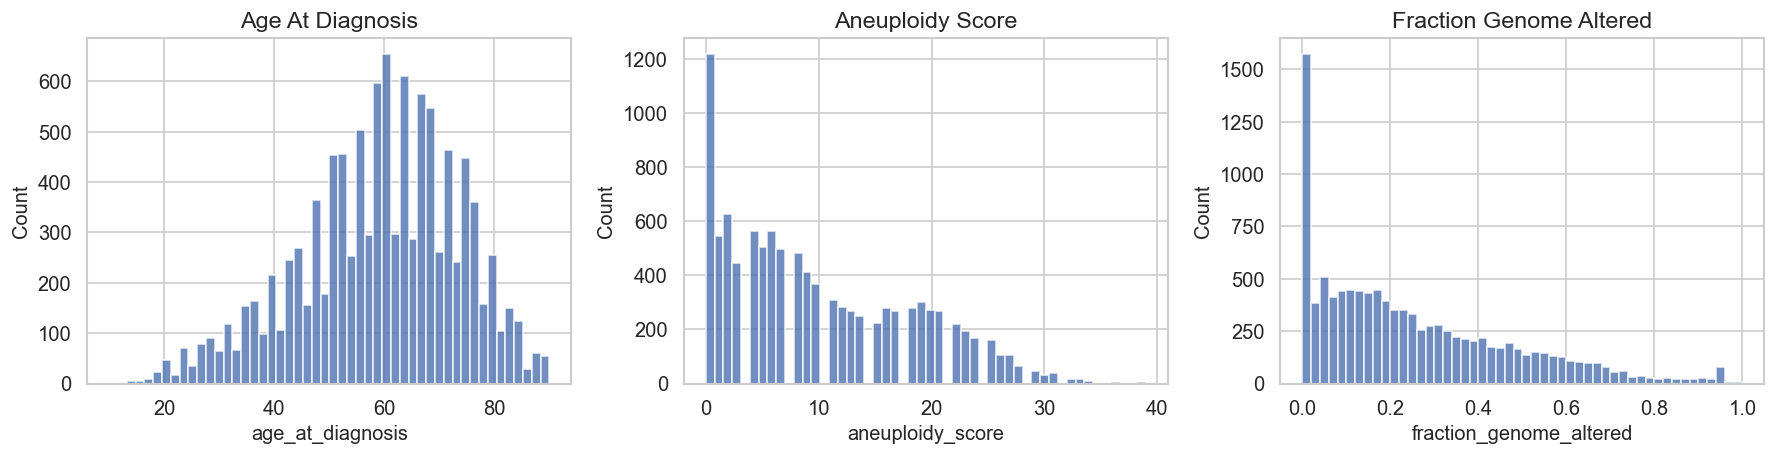

In [9]:
# Continuous predictors
cont_predictors = ["age_at_diagnosis", "aneuploidy_score", "fraction_genome_altered"]
available = [c for c in cont_predictors if c in df.columns]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 4))
    if len(available) == 1:
        axes = [axes]
    for ax, col in zip(axes, available):
        data = df[col].dropna()
        ax.hist(data, bins=50, edgecolor="white", alpha=0.8)
        ax.set_title(col.replace("_", " ").title())
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
    fig.tight_layout()
    save_fig(fig, "predictor_distributions_continuous", FIGURES_DIR)
    plt.show()

  Saved: predictor_distributions_categorical.png, predictor_distributions_categorical.pdf


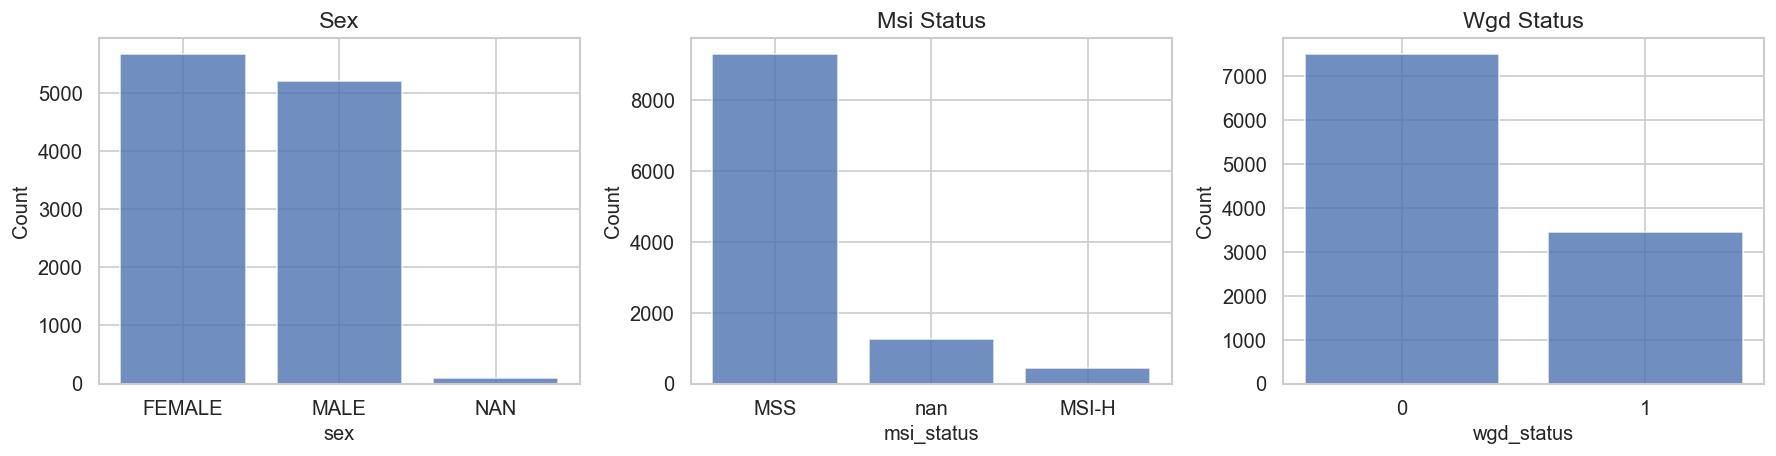

In [10]:
# Categorical predictors
cat_predictors = ["sex", "msi_status", "wgd_status"]
available_cats = [c for c in cat_predictors if c in df.columns]

if available_cats:
    fig, axes = plt.subplots(1, len(available_cats), figsize=(5 * len(available_cats), 4))
    if len(available_cats) == 1:
        axes = [axes]
    for ax, col in zip(axes, available_cats):
        counts = df[col].value_counts(dropna=False)
        ax.bar(counts.index.astype(str), counts.values, alpha=0.8)
        ax.set_title(col.replace("_", " ").title())
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
    fig.tight_layout()
    save_fig(fig, "predictor_distributions_categorical", FIGURES_DIR)
    plt.show()

## 5. Bivariate Relationships with log(TMB)

  Saved: bivariate_continuous.png, bivariate_continuous.pdf


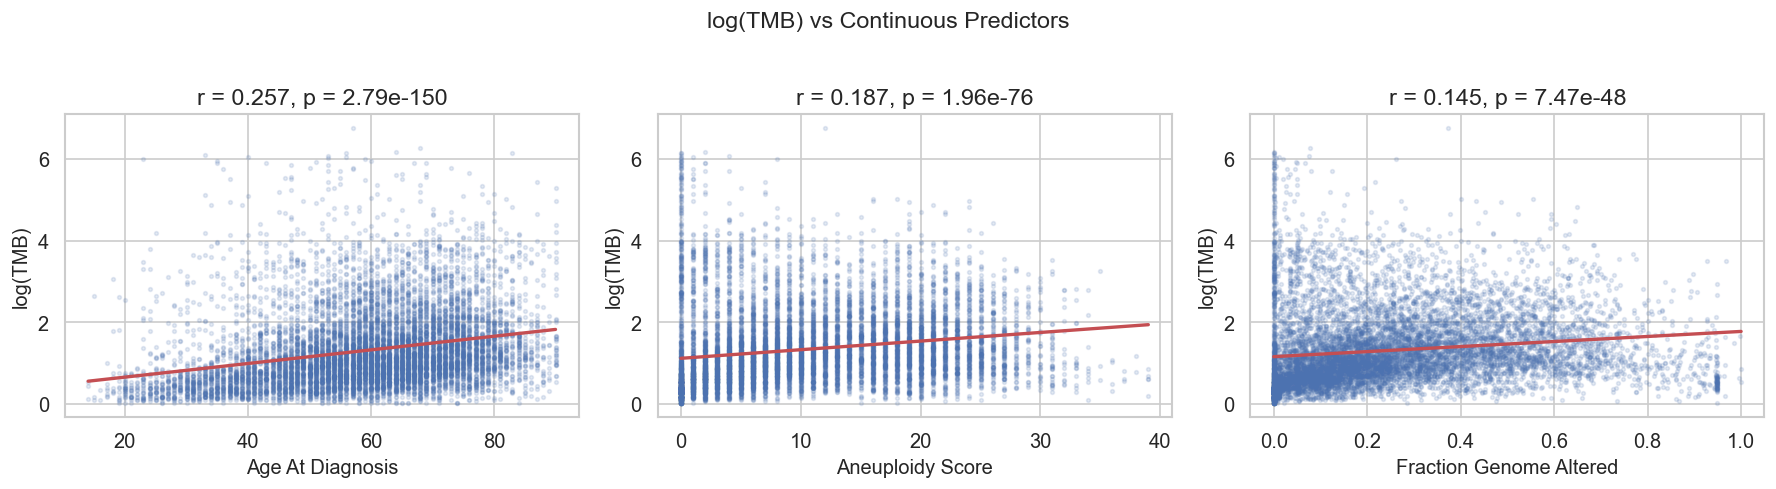

In [11]:
# Scatter plots: log_tmb vs continuous predictors
if available:
    fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 4))
    if len(available) == 1:
        axes = [axes]
    for ax, col in zip(axes, available):
        subset = df[[col, "log_tmb"]].dropna()
        ax.scatter(subset[col], subset["log_tmb"], alpha=0.15, s=5)
        # Add regression line
        z = np.polyfit(subset[col], subset["log_tmb"], 1)
        p = np.poly1d(z)
        x_range = np.linspace(subset[col].min(), subset[col].max(), 100)
        ax.plot(x_range, p(x_range), "r-", lw=2)
        r, pval = stats.pearsonr(subset[col], subset["log_tmb"])
        ax.set_title(f"r = {r:.3f}, p = {pval:.2e}")
        ax.set_xlabel(col.replace("_", " ").title())
        ax.set_ylabel("log(TMB)")
    fig.suptitle("log(TMB) vs Continuous Predictors", fontsize=14, y=1.02)
    fig.tight_layout()
    save_fig(fig, "bivariate_continuous", FIGURES_DIR)
    plt.show()

  Saved: bivariate_categorical.png, bivariate_categorical.pdf


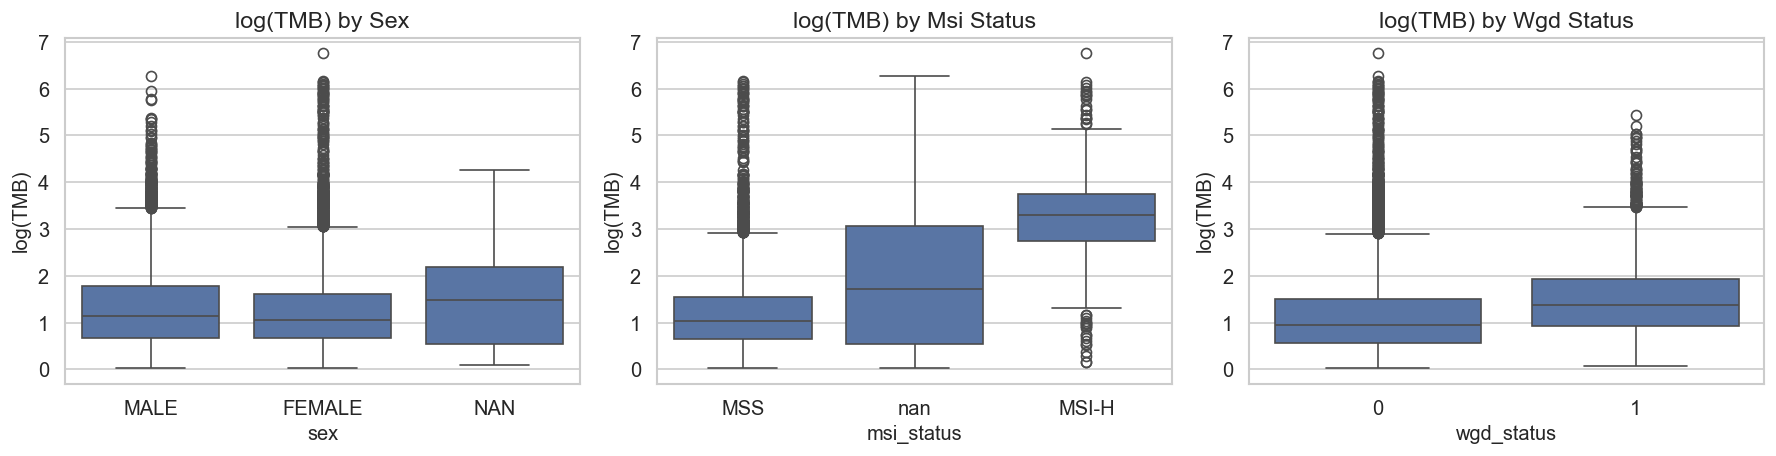

In [12]:
# Box plots: log_tmb by categorical predictors
if available_cats:
    fig, axes = plt.subplots(1, len(available_cats), figsize=(5 * len(available_cats), 4))
    if len(available_cats) == 1:
        axes = [axes]
    for ax, col in zip(axes, available_cats):
        subset = df[[col, "log_tmb"]].dropna()
        sns.boxplot(data=subset, x=col, y="log_tmb", ax=ax)
        ax.set_title(f"log(TMB) by {col.replace('_', ' ').title()}")
        ax.set_xlabel(col)
        ax.set_ylabel("log(TMB)")
    fig.tight_layout()
    save_fig(fig, "bivariate_categorical", FIGURES_DIR)
    plt.show()

## 6. Correlation Heatmap

  Saved: correlation_heatmap.png, correlation_heatmap.pdf


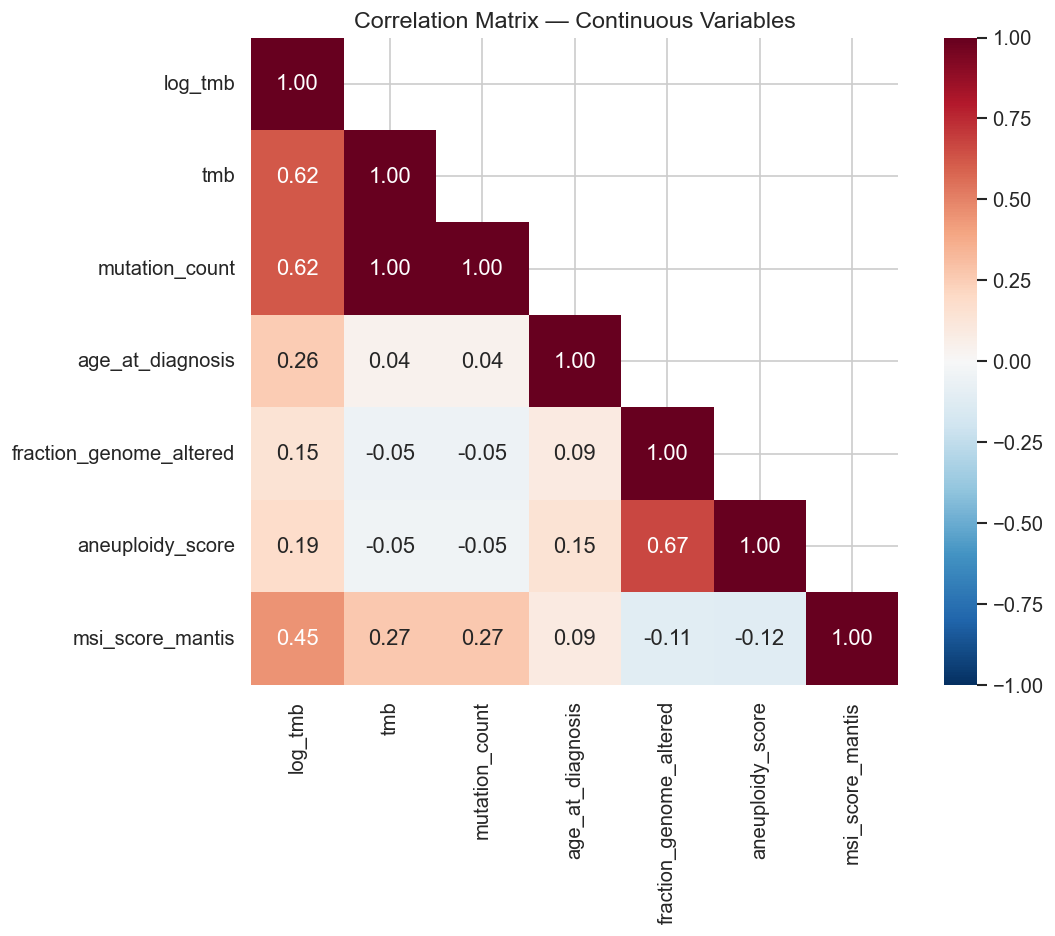

In [13]:
corr_cols = ["log_tmb", "tmb", "mutation_count", "age_at_diagnosis",
             "fraction_genome_altered", "aneuploidy_score", "msi_score_mantis"]
available_corr = [c for c in corr_cols if c in df.columns]

if len(available_corr) >= 3:
    corr_matrix = df[available_corr].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt=".2f",
        cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        square=True, ax=ax,
    )
    ax.set_title("Correlation Matrix — Continuous Variables")
    fig.tight_layout()
    save_fig(fig, "correlation_heatmap", FIGURES_DIR)
    plt.show()

## 7. Key Findings

**TMB distribution:**
- Raw TMB is heavily right-skewed; log-transformation substantially improves normality
- The FDA TMB-high cutoff (≥10 mut/Mb) captures the upper tail of the distribution

**Cancer type variation:**
- SKCM (melanoma) and UCEC (endometrial) show the highest median TMB, consistent with known biology
- TMB-high prevalence varies dramatically across cancer types

**Predictor relationships:**
- Cancer type is expected to be the dominant predictor
- MSI status (where available) shows strong association with TMB
- Age, aneuploidy score, and FGA show varying correlations with TMB

**Potential collinearity:**
- Aneuploidy score and fraction genome altered are likely correlated — will assess with VIF in regression notebooks